In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.isnull().sum()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


# Features
###### AT — Ambient Temperature
###### V — Exhaust Vacuum
###### AP — Ambient Pressure
###### RH — Relative Humidity
###### PE — Produced Energy(Target)

In [4]:
X = df.drop("PE",axis = 1)
y = df["PE"]

## Data Split

In [5]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size = 0.2 , random_state = 42
)

## Scaling

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Creating Tensors

In [7]:
import torch 
import torch.nn as nn 

In [8]:
X_train_tensor = torch.tensor(X_train_scaled , dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values , dtype = torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled , dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values , dtype = torch.float32).view(-1,1)

In [9]:
y_test_tensor

tensor([[433.2700],
        [438.1600],
        [458.4200],
        ...,
        [467.8000],
        [437.1400],
        [456.7800]])

## TensorDataset & DataLoader

In [10]:
from torch.utils.data import TensorDataset , DataLoader

train_dataset = TensorDataset(X_train_tensor , y_train_tensor)
test_dataset = TensorDataset(X_test_tensor , y_test_tensor)

In [11]:
train_loader = DataLoader(train_dataset , batch_size = 32 , shuffle = True)
test_loader = DataLoader(test_dataset , batch_size = 32)

# Deep Learning

## Defining ANN Model

In [12]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN , self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1] , 6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # Output Layer
            nn.Linear(6,1),
        )
    def forward(self,x):
        return self.model(x)

In [13]:
model = ANN()

## Loss & Optimizer

In [14]:
import torch.optim as optim

crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

## Train ANN

In [15]:
epochs = 100

train_losses = []
val_losses = [] 
best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb , yb in train_loader:
        # xb = features of single batch
        # yb = labels of single batch 

        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop.. predicted outputs for this batch
        loss = crietrion(outputs , yb) # compute loss
        loss.backward() # backward prop.. compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # Loss is tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # No gradients to compute 
        for xb , yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs,yb)
            running_val_loss += loss


    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch} : train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict() , "best_model.pt") # .pt .pth

epoch 0 : train loss = 205903.29811197918 & val loss = 204059.34375
epoch 1 : train loss = 197606.5603515625 & val loss = 186810.78125
epoch 2 : train loss = 167601.011328125 & val loss = 144277.765625
epoch 3 : train loss = 116030.17242838541 & val loss = 87815.9296875
epoch 4 : train loss = 62948.358561197914 & val loss = 42547.25
epoch 5 : train loss = 29678.737357584636 & val loss = 21237.970703125
epoch 6 : train loss = 16915.685693359374 & val loss = 14306.111328125
epoch 7 : train loss = 12555.816292317708 & val loss = 11221.1572265625
epoch 8 : train loss = 9969.112980143229 & val loss = 8832.00390625
epoch 9 : train loss = 7784.1708974202475 & val loss = 6770.767578125
epoch 10 : train loss = 5899.544534301758 & val loss = 5023.7890625
epoch 11 : train loss = 4310.518185933431 & val loss = 3608.40966796875
epoch 12 : train loss = 3071.8026392618817 & val loss = 2556.1259765625
epoch 13 : train loss = 2137.824353790283 & val loss = 1786.778076171875
epoch 14 : train loss = 1479

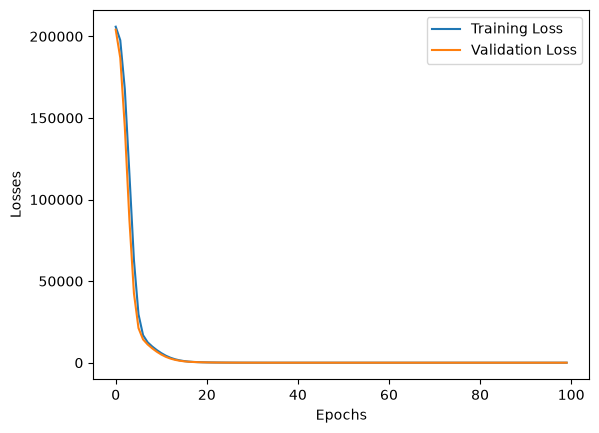

In [16]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training_Loss":train_losses,
    "Validation_Loss":val_losses,
})

plt.plot(loss_df["Training_Loss"] , label = "Training Loss")
plt.plot(loss_df["Validation_Loss"] , label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

## Loading the Best Model

In [17]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

## Evaluation

In [18]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)


    train_mse_loss = crietrion(train_preds , y_train_tensor)
    test_mse_loss = crietrion(test_preds , y_test_tensor)
    

print(f"Training MSE : {train_mse_loss.item()}")
print(f"Testing MSE : {test_mse_loss.item()}")

Training MSE : 20.628286361694336
Testing MSE : 18.824609756469727


In [19]:
from sklearn.metrics import r2_score
print(f"r^2 Score : {r2_score( y_test,test_preds)}")

r^2 Score : 0.9342128438504677


In [20]:
pridicted_df = pd.DataFrame(test_preds.numpy(), columns = ["Predicted Values"])
actual_df = pd.DataFrame(y_test.values , columns = ["Actual Values"])

pd.concat([pridicted_df,actual_df], axis = 1)

,Predicted Values,Actual Values
0,434.949463,433.27
1,436.398987,438.16
2,461.344421,458.42
3,476.253143,480.82
4,435.124146,441.41
...,...,...
1909,451.045471,456.70
1910,431.205811,438.04
1911,467.394012,467.80
1912,430.591919,437.14
